### **Python DA-Module End-5**


### **Project Title: Social Media Engagement Analytics Using Python**


#### **Problem Statement:**
##### Social media platforms generate massive volumes of engagement data—likes, comments, shares, impressions, watch time, and more. Analyzing such data helps companies understand user behavior, identify trends, and improve content performance.
##### In this assignment, you will work with a social media dataset containing social media engagement metrics. The task involves data cleaning, transformation, NumPy/Pandas operations, exploratory data analysis, visualizations, and generating insights.


#### **Assignment Tasks**
##### **Task 1 — Data Import & Setup**
##### Import CSV using Pandas
##### Check/convert data types
##### Convert date columns to datetime






In [105]:
import pandas as pd
import numpy as np

df = pd.read_csv("social media.csv")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [107]:
df['age'] = df['age'].astype('Int64')
df['likes'] = df['likes'].astype('Int64')
df['comments'] = df['comments'].astype('Int64')
df['shares'] = df['shares'].astype('Int64')
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   Int64         
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   Int64         
 8   comments          4850 non-null   Int64         
 9   shares            4850 non-null   Int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

/tmp/ipykernel_3653/1909626579.py:5: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



#### **Task 2 — Data Cleaning**
 ##### **Cleaning Missing Data**
##### Detect missing values (isnull(), isna())
#####Handle using: dropna(), fillna(), median/mode, forward/backward-fill


In [108]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [109]:
#Handling Missing Values

df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(round(df['likes'].median()))
df['comments'] = df['comments'].fillna(round(df['comments'].median()))
df['shares'] = df['shares'].fillna(round(df['shares'].median()))
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])
df.isnull().sum()


,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [110]:
df.sample(10)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
2990,97960,52,Female,Australia,754492,reel,education,10106,447,558,3689,52650,2023-04-29,70812,True,tablet,negative,#fashion #lifestyle #love,0.295423
2513,12461,24,Male,France,186390,image,education,310,2288,1804,7322,45131,2023-02-15,33364,False,tablet,positive,#foodie,0.097538
135,60015,14,Female,Canada,218251,reel,food,7798,1521,732,2160,48058,2022-12-11,16065,False,desktop,neutral,#travel,0.209143
191,33664,31,Female,Japan,628089,reel,food,1280,1180,76,3400,30512,2022-03-14,729329,False,tablet,negative,#reels,0.083115
2323,65099,51,Other,Brazil,287031,text,tech,6844,1497,1075,49,13439,2022-06-23,463756,False,mobile,positive,#travel #music,0.784136
4367,20751,27,Male,Japan,412646,video,tech,6659,1959,1311,2816,27633,2023-10-18,574421,False,desktop,negative,#lifestyle #fitness #tech,0.359317
3377,19569,32,Female,UAE,875381,reel,fitness,8401,834,1321,61,30767,2022-01-25,390792,False,tablet,positive,#lifestyle,0.343095
2568,98199,38,Other,Germany,284126,text,fitness,12644,2690,484,1037,87621,2022-10-19,724400,False,tablet,positive,#foodie,0.180527
403,42093,38,Male,Germany,224809,text,fitness,8903,825,136,7289,11984,2023-03-26,611234,False,tablet,neutral,#travel #music,0.823097
3079,45292,30,Other,France,703015,video,fashion,3097,533,860,1224,20733,2023-07-20,331942,True,desktop,negative,#fashion #fun #fitness,0.216563


##### **Duplicate Handling- Identify & remove duplicates**


In [111]:
# Drop the Duplicates
df.drop_duplicates(subset='user_id', keep='first', inplace=True)
df.duplicated('user_id').sum()

np.int64(0)

In [112]:
df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4862 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4862 non-null   int64         
 1   age               4862 non-null   Int64         
 2   gender            4862 non-null   object        
 3   country           4862 non-null   object        
 4   post_id           4862 non-null   int64         
 5   post_type         4862 non-null   object        
 6   post_category     4862 non-null   object        
 7   likes             4862 non-null   Int64         
 8   comments          4862 non-null   Int64         
 9   shares            4862 non-null   Int64         
 10  watch_time_sec    4862 non-null   int64         
 11  impression_count  4862 non-null   int64         
 12  posted_at         4862 non-null   datetime64[ns]
 13  follower_count    4862 non-null   int64         
 14  is_verified       4862 non-nu

##### **Data Formatting**
##### Fix incorrect data types
##### Standardize categories (e.g., gender labels)
##### Correct unrealistic values in likes, comments, shares


In [113]:
df['gender'] = df['gender'].str.lower().str.strip()
df['gender'].value_counts()

,count
gender,
male,1798
other,1544
female,1520


In [114]:
df[['likes', 'comments', 'shares']].describe()

,likes,comments,shares
count,4862.0,4862.0,4862.0
mean,10099.624434,1502.718223,1001.640066
std,5707.260446,856.659313,570.185652
min,10.0,0.0,0.0
25%,5208.25,791.0,510.0
50%,10106.0,1497.0,1012.0
75%,14920.25,2234.75,1476.75
max,19998.0,2999.0,1999.0


##### **Feature Cleaning**
##### Extract hashtag count
##### Clean sentiment labels


In [115]:
# Hashtag count
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))

# Clean sentiment
df['sentiment'] = df['sentiment'].str.lower().str.strip()
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3


#### **Task 3 — Data Exploration using Pandas**


##### **Perform the following:**
##### *View dataset structure using head(), tail(), shape, and columns.
##### *Check data types and info with info() and dtypes.
##### *Generate summary statistics using describe().
##### *Analyze categorical distributions using value_counts(), unique(), and nunique().
##### *Create a correlation matrix for numeric fields.
##### *Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).


In [116]:
#View Dataset Structure

df.head(10)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1
5,92386,16,other,Canada,174310,video,tech,12535,1790,99,1427,24893,2023-09-16,684761,False,desktop,positive,#fitness,0.579440,1
6,47194,25,male,Japan,481598,video,travel,11703,2276,1465,6287,96327,2022-04-15,519759,True,tablet,negative,#music,0.160329,1
7,97498,57,female,Canada,343415,image,travel,9611,146,424,1699,68446,2023-12-20,698739,False,desktop,neutral,#travel #music #fitness,0.148745,3
8,54131,54,female,UK,907449,image,fashion,10106,2379,1897,5650,36283,2023-07-06,615809,True,desktop,negative,#music #fun #fitness,0.533914,3
9,70263,62,female,Australia,495037,video,lifestyle,14106,2480,1053,3969,87972,2022-11-16,452146,False,tablet,neutral,#lifestyle #love,0.200507,2


In [117]:
df.tail(3)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4997,67021,63,female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [118]:
df.shape

(4862, 20)

In [119]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [120]:
#Check Datatypes & info

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4862 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4862 non-null   int64         
 1   age               4862 non-null   Int64         
 2   gender            4862 non-null   object        
 3   country           4862 non-null   object        
 4   post_id           4862 non-null   int64         
 5   post_type         4862 non-null   object        
 6   post_category     4862 non-null   object        
 7   likes             4862 non-null   Int64         
 8   comments          4862 non-null   Int64         
 9   shares            4862 non-null   Int64         
 10  watch_time_sec    4862 non-null   int64         
 11  impression_count  4862 non-null   int64         
 12  posted_at         4862 non-null   datetime64[ns]
 13  follower_count    4862 non-null   int64         
 14  is_verified       4862 non-nu

In [121]:
df.dtypes

,0
user_id,int64
age,Int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,Int64
comments,Int64
shares,Int64


In [122]:
#Summary Statistics

df.describe().round(2)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,4862.00,4862.0,4862.00,4862.0,4862.0,4862.0,4862.00,4862.00,4862,4862.00,4862.00,4862.00
mean,54666.07,38.47,548814.39,10099.62,1502.72,1001.64,4016.29,50037.79,2022-12-27 14:17:43.266145536,394125.56,0.97,2.00
min,10055.00,13.0,100068.00,10.0,0.0,0.0,0.00,105.00,2022-01-01 00:00:00,87.00,0.01,1.00
25%,32422.75,26.0,324873.75,5208.25,791.0,510.0,2015.50,25074.75,2022-07-02 00:00:00,194741.00,0.15,1.00
50%,54458.50,38.0,549198.50,10106.0,1497.0,1012.0,4054.00,49914.50,2022-12-26 00:00:00,389665.50,0.25,2.00
75%,77347.50,51.0,771088.25,14920.25,2234.75,1476.75,6019.75,74755.25,2023-06-25 18:00:00,590151.00,0.50,3.00
max,99963.00,64.0,999455.00,19998.0,2999.0,1999.0,7998.00,99995.00,2023-12-31 00:00:00,799533.00,191.50,3.00
std,26128.62,14.7,259801.04,5707.26,856.66,570.19,2309.12,28855.39,NaN,231023.85,5.39,0.81


In [123]:
#Analyse Categorical Distribution

cols = ['gender','country','post_type','post_category','device_type','sentiment','hashtags']

for col in cols:
    print(f"\n{col.upper()} DISTRIBUTION:")
    print(df[col].value_counts())


GENDER DISTRIBUTION:
gender
male      1798
other     1544
female    1520
Name: count, dtype: int64

COUNTRY DISTRIBUTION:
country
India        524
Canada       493
Brazil       489
UAE          488
USA          487
France       485
Australia    484
UK           476
Germany      476
Japan        460
Name: count, dtype: int64

POST_TYPE DISTRIBUTION:
post_type
reel     1242
image    1215
text     1210
video    1195
Name: count, dtype: int64

POST_CATEGORY DISTRIBUTION:
post_category
fitness      660
tech         650
music        616
education    608
lifestyle    592
travel       582
fashion      581
food         573
Name: count, dtype: int64

DEVICE_TYPE DISTRIBUTION:
device_type
mobile     1632
tablet     1622
desktop    1608
Name: count, dtype: int64

SENTIMENT DISTRIBUTION:
sentiment
positive    2435
neutral     1489
negative     938
Name: count, dtype: int64

HASHTAGS DISTRIBUTION:
hashtags
#tech                          193
#love                          172
#fitness               

In [124]:
for col in cols:
    print(f"\nUnique values for {col.upper()}:")
    if col == 'hashtags':
        print(f"Number of unique hashtag combinations: {df[col].nunique()}")
        print("Displaying only the first 5 unique hashtag combinations due to high cardinality:")
        print(df[col].unique()[:5])
    else:
        print(df[col].unique())


Unique values for GENDER:
['female' 'male' 'other']

Unique values for COUNTRY:
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

Unique values for POST_TYPE:
['image' 'reel' 'text' 'video']

Unique values for POST_CATEGORY:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

Unique values for DEVICE_TYPE:
['mobile' 'tablet' 'desktop']

Unique values for SENTIMENT:
['negative' 'positive' 'neutral']

Unique values for HASHTAGS:
Number of unique hashtag combinations: 757
Displaying only the first 5 unique hashtag combinations due to high cardinality:
['#foodie #travel #love' '#fitness' '#foodie' '#music #foodie #fun'
 '#travel']


In [125]:
for col in cols:
    print(f"\nnunique values for {col.upper()}:")
    if col == 'hashtags':
        print(f"Number of unique hashtag combinations: {df[col].nunique()}")
        print("Displaying only the first 5 unique hashtag combinations due to high cardinality:")
        print(df[col].unique()[:5])
    else:
        print(df[col].nunique())


nunique values for GENDER:
3

nunique values for COUNTRY:
10

nunique values for POST_TYPE:
4

nunique values for POST_CATEGORY:
8

nunique values for DEVICE_TYPE:
3

nunique values for SENTIMENT:
3

nunique values for HASHTAGS:
Number of unique hashtag combinations: 757
Displaying only the first 5 unique hashtag combinations due to high cardinality:
['#foodie #travel #love' '#fitness' '#foodie' '#music #foodie #fun'
 '#travel']


In [126]:
# Correlation Matrix

corr = df.corr(numeric_only=True).round(2)
corr

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.00,-0.01,0.02,0.02,-0.03,0.01,-0.02,0.01,0.01,0.00,-0.00,-0.01
age,-0.01,1.00,-0.01,-0.04,-0.01,0.01,0.01,0.02,-0.03,0.00,0.01,0.01
post_id,0.02,-0.01,1.00,0.01,-0.01,0.01,0.01,-0.01,-0.00,0.03,0.01,0.00
likes,0.02,-0.04,0.01,1.00,-0.02,0.01,0.01,0.01,-0.02,-0.02,0.09,-0.00
comments,-0.03,-0.01,-0.01,-0.02,1.00,0.00,-0.02,-0.01,-0.01,-0.01,-0.00,-0.01
shares,0.01,0.01,0.01,0.01,0.00,1.00,0.02,-0.00,-0.01,0.01,0.02,0.01
watch_time_sec,-0.02,0.01,0.01,0.01,-0.02,0.02,1.00,-0.01,0.00,0.01,-0.00,-0.03
impression_count,0.01,0.02,-0.01,0.01,-0.01,-0.00,-0.01,1.00,-0.01,0.01,-0.23,-0.00
follower_count,0.01,-0.03,-0.00,-0.02,-0.01,-0.01,0.00,-0.01,1.00,-0.02,0.00,0.01
is_verified,0.00,0.00,0.03,-0.02,-0.01,0.01,0.01,0.01,-0.02,1.00,0.01,0.00


In [127]:
# Groupby

df.groupby('post_type')['likes'].mean().round(2)

,likes
post_type,
image,10037.55
reel,9984.69
text,10156.96
video,10224.14


In [128]:
df.groupby('country')['impression_count'].mean().round(2)

,impression_count
country,
Australia,48498.08
Brazil,49178.96
Canada,49008.08
France,51740.24
Germany,48727.41
India,52561.70
Japan,49390.99
UAE,48695.26
UK,51280.00


In [129]:
df.groupby(['post_type','country']).agg({'likes':'mean','impression_count':'mean'}).round(2)

likes  impression_count
post_type country                              
image     Australia   9574.29          43966.67
          Brazil      9287.29          51195.85
          Canada      9497.84          45908.19
          France     11170.11          51976.84
          Germany    10126.54          51904.75
          India      10098.02          54157.80
          Japan        9608.2          45528.06
          UAE        10753.05          48486.87
          UK          9812.08          54666.75
          USA        10532.49          49395.92
reel      Australia  10150.51          50605.75
          Brazil      9739.79          51368.15
          Canada     10129.02          51423.88
          France     10061.44          49677.88
          Germany      9361.0          45913.94
          India        9532.9          55207.32
          Japan      10079.61          48893.71
          UAE         9963.32          50541.32
          UK         10535.69          50556.29
          USA        10406.41          47825.28
text      Australia  10359.86          50227.08
          Brazil     10321.08          46674.34
          Canada     10172.77          49366.66
          France       9812.1          55491.54
          Germany    10661.85          45527.89
          India      10244.98          51118.28
          Japan       9951.05          50842.92
          UAE        10149.04          49661.11
          UK          9716.45          48085.04
          USA        10111.84          53750.02
video     Australia  10976.09          49288.66
          Brazil     10103.75          47084.42
          Canada     10245.76          49618.28
          France     10581.62          49719.09
          Germany    10298.38          51658.29
          India      10142.33          48762.08
          Japan      10359.08          51690.57
          UAE         9936.54          45771.81
          UK          9808.87          51572.23
          USA         9786.83          52852.76

##### **Task 4 — Data Wrangling**
##### Use merge, concat, or join if combining DataFrames.
##### Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.
##### Perform groupby summaries by post_type, country, and sentiment.



In [130]:
#Merge

df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43,female,Brazil,496713,image,fitness,7011,354,1157,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522
1,10860,33,male,Brazil,157326,reel,food,11750,2606,1807,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163
2,86820,32,female,UK,109864,text,food,4862,344,955,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161
3,64886,51,other,France,848877,text,fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482
4,16265,34,other,UK,449706,image,fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,male,Australia,441541,video,education,16210,2013,1837,...,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2,20060
4996,22100,38,other,UAE,677076,reel,education,16924,2734,1583,...,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2,21241
4997,67021,63,female,USA,273595,text,travel,13487,1497,167,...,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2,15151
4998,29800,13,female,Germany,785644,video,fitness,16894,1289,1713,...,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3,19896


In [131]:
df.groupby(['post_type', 'country', 'sentiment']).agg(avg_likes=('likes', 'mean'), avg_impression_count=('impression_count', 'mean')).round(2)

avg_likes  avg_impression_count
post_type country   sentiment                                 
image     Australia negative     8006.16              42385.84
                    neutral       9662.0              43816.02
                    positive     9990.14              44541.48
          Brazil    negative     7559.35              48747.95
                    neutral      8192.09              50831.66
...                                  ...                   ...
video     UK        neutral     10291.08              44391.28
                    positive     9016.74              53780.06
          USA       negative    10290.45              54831.05
                    neutral      9582.21              58830.28
                    positive     9748.09              47802.96

[120 rows x 2 columns]

##### **Task 5 — Statistical Analysis**
##### **Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:**
##### Mean, median, mode
##### Standard deviation, variance Percentiles
##### (Optional) Skewness and kurtosis


In [132]:
# Descriptive Statistics without looping:

cols = ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']

print(df[cols].mean())
print(df[cols].median())
print(df[cols].std())
print(df[cols].var())
print(df[cols].quantile([0.25, 0.5, 0.75]))



likes               10099.624434
comments             1502.718223
shares               1001.640066
watch_time_sec       4016.287536
engagement_rate         0.972642
follower_count     394125.555533
dtype: Float64
likes               10106.0
comments             1497.0
shares               1012.0
watch_time_sec       4054.0
engagement_rate     0.25318
follower_count     389665.5
dtype: Float64
likes                5707.260446
comments              856.659313
shares                570.185652
watch_time_sec       2309.115545
engagement_rate         5.387479
follower_count     231023.848864
dtype: Float64
likes                 32572821.796794
comments                733865.178763
shares                  325111.677456
watch_time_sec         5332014.600293
engagement_rate             29.024927
follower_count     53372018743.934204
dtype: Float64
         likes  comments   shares  watch_time_sec  engagement_rate  \
0.25   5208.25     791.0    510.0         2015.50         0.145443   
0.50   1

In [133]:
#Descriptive Statistics with looping

column = ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']

operations = ['mean', 'median','mode','std', 'var','skew','kurt']

for op in operations:
    print(f"\n{op.upper()}:\n")
    print(getattr(df[column], op)().round(2))

print("\nQUANTILES:\n")
print(df[column].quantile([0.25, 0.5, 0.75]))


MEAN:

likes               10099.62
comments             1502.72
shares               1001.64
watch_time_sec       4016.29
engagement_rate         0.97
follower_count     394125.56
dtype: Float64

MEDIAN:

likes               10106.0
comments             1497.0
shares               1012.0
watch_time_sec       4054.0
engagement_rate        0.25
follower_count     389665.5
dtype: Float64

MODE:

      likes  comments  shares  watch_time_sec  engagement_rate  follower_count
0     10106      1497    1012           916.0             0.01        497502.0
1      <NA>      <NA>    <NA>          2145.0             0.01             NaN
2      <NA>      <NA>    <NA>          4360.0             0.01             NaN
3      <NA>      <NA>    <NA>          7003.0             0.02             NaN
4      <NA>      <NA>    <NA>          7688.0             0.02             NaN
...     ...       ...     ...             ...              ...             ...
4857   <NA>      <NA>    <NA>             NaN    

##### **Task 6 — Data Visualization**
##### **Matplotlib**
##### Scatter: likes vs impressions
##### Line: daily engagement trend
##### Bar: posts by category
##### Pie: gender distribution
##### Histogram: age
##### Box: engagement rate



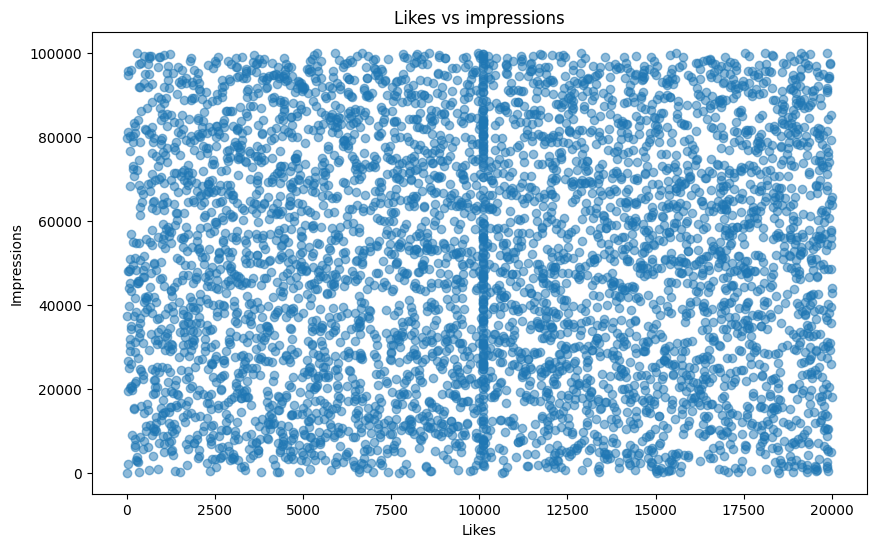

In [134]:
#Scatter: likes vs impressions

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['likes'],df['impression_count'],alpha=0.5)
plt.title('Likes vs impressions')
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.show()

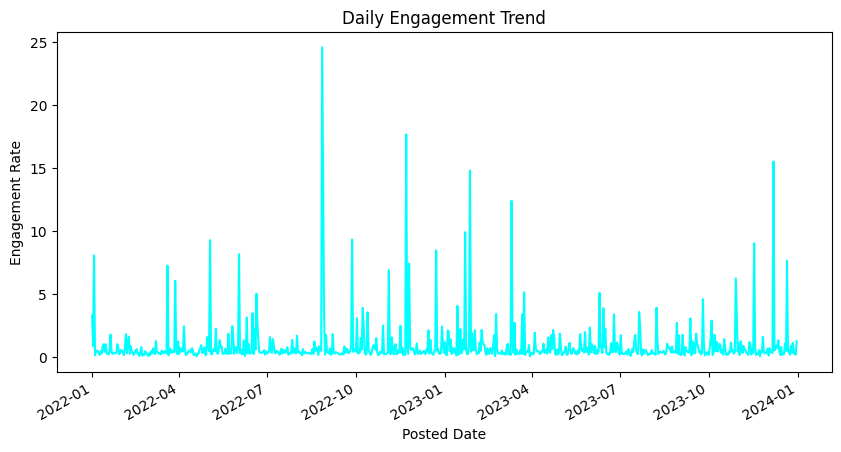

In [135]:
#Line: daily engagement trend

df.groupby('posted_at')['engagement_rate'].mean().plot(figsize=(10,5),color='cyan')
plt.title("Daily Engagement Trend")
plt.xlabel("Posted Date")
plt.ylabel("Engagement Rate")
plt.show()

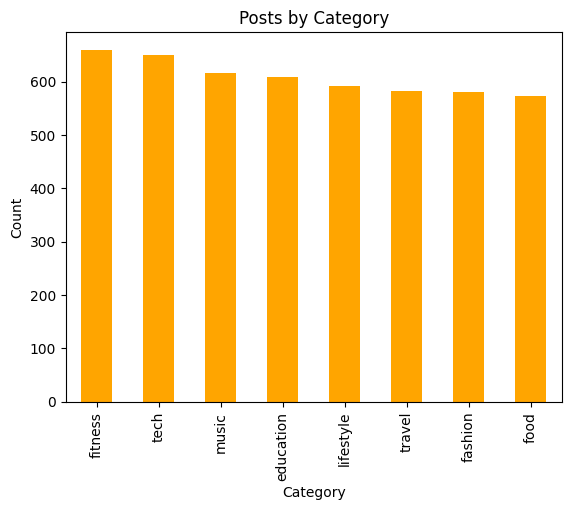

In [136]:
df['post_category'].value_counts().plot(kind='bar',color='orange')
plt.title("Posts by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

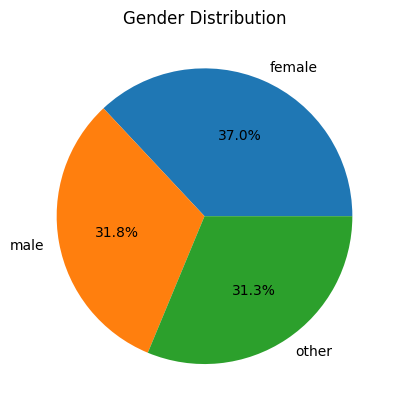

In [137]:
#Pie: gender distribution

plt.pie(df['gender'].value_counts(),labels=df['gender'].unique(),autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()


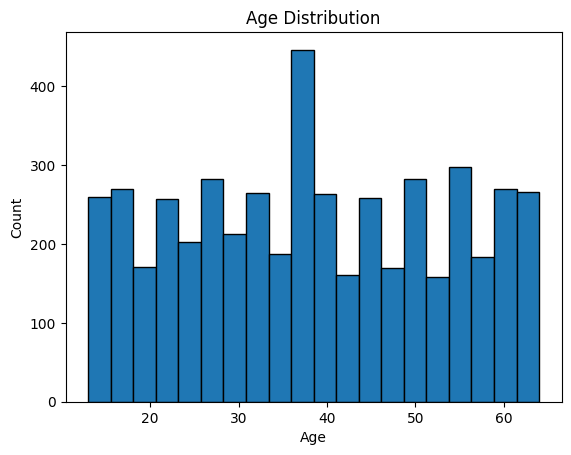

In [138]:
#Histogram: age

plt.hist(df['age'],bins=20,edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

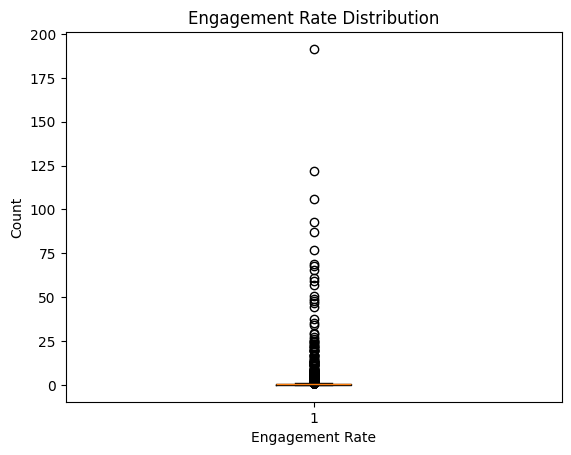

In [139]:
#Box: engagement rate

plt.boxplot(df['engagement_rate'],vert=True)
plt.title("Engagement Rate Distribution")
plt.xlabel("Engagement Rate")
plt.ylabel("Count")
plt.show()

##### **Seaborn:**

##### Count plot: post type
##### Bar plot: avg likes by category
##### Violin: followers vs sentiment
##### Pair plot: numeric features
##### Heatmap: correlation matrix
##### Swarm plot: engagement vs device


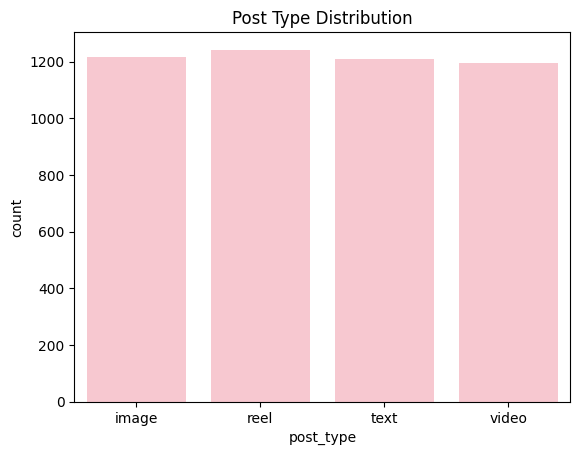

In [140]:
#Count plot: post type

import seaborn as sns

plt.figure()
sns.countplot(data=df,x='post_type',color="pink")
plt.title("Post Type Distribution")
plt.show()

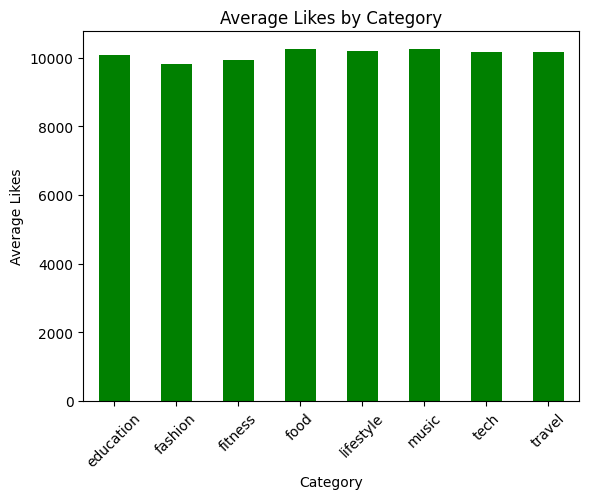

In [141]:
#Bar plot: avg likes by category

df.groupby('post_category')['likes'].mean().plot(kind='bar',color='green')
plt.title("Average Likes by Category")
plt.xlabel("Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.show()

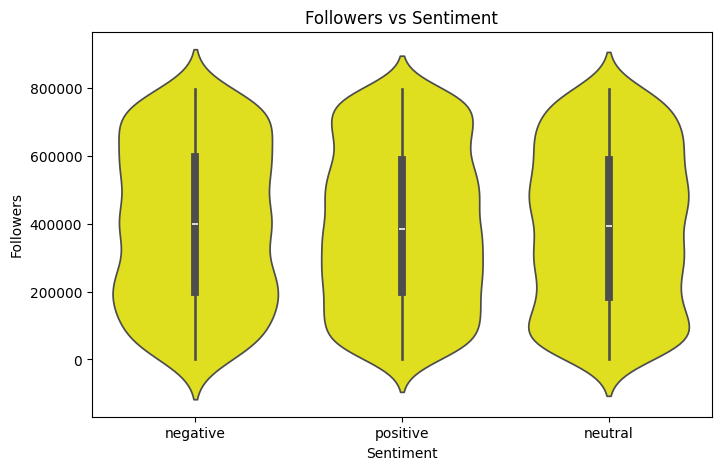

In [142]:
#Violin: followers vs sentiment

plt.figure(figsize=(8,5))
sns.violinplot(data=df,x='sentiment',y='follower_count',color='yellow')
plt.title("Followers vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Followers")
plt.show()


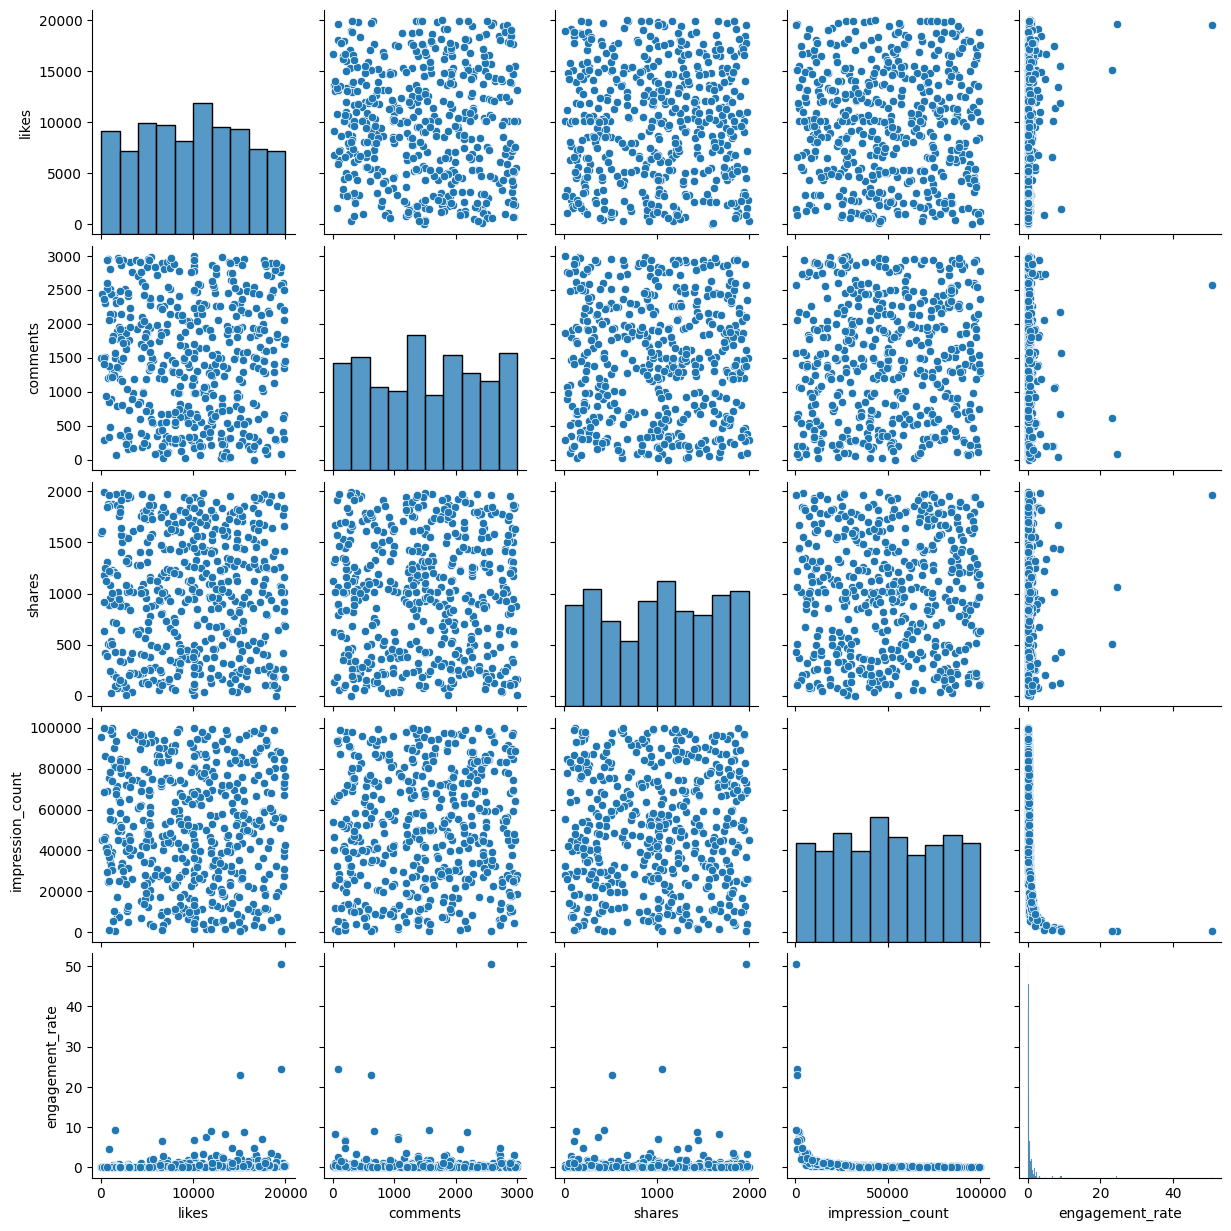

In [143]:
#Pair plot: numeric features

colm = ['likes', 'comments', 'shares', 'impression_count', 'engagement_rate']
sns.pairplot(df[colm].sample(500))
plt.show()

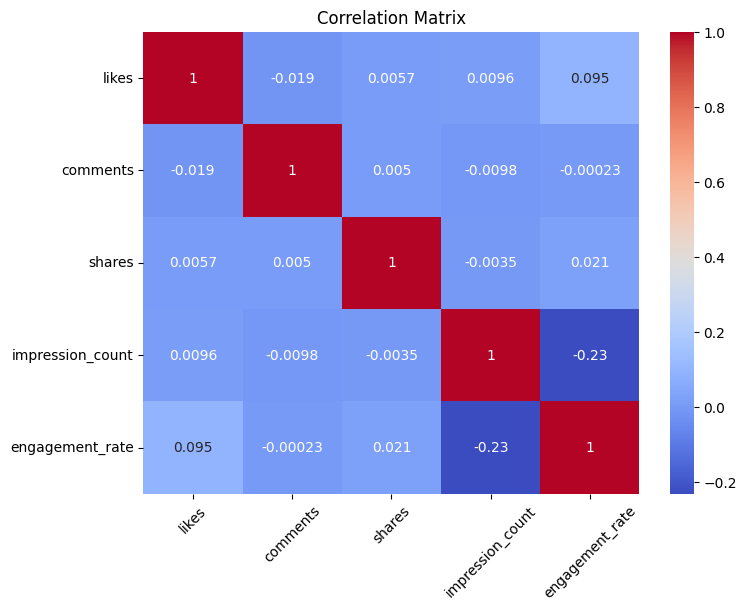

In [144]:
#Heatmap: correlation matrix

cols = ['likes', 'comments', 'shares', 'impression_count', 'engagement_rate']
corr = df[cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

##### **Plotly (Interactive)**
##### Interactive line chart/bar chart/bubble/scatter chart


In [145]:
#Bubble chart

import plotly.express as px

fig = px.scatter(
    df,
    x='likes',
    y='impression_count',
    size='engagement_rate',
    color='post_type',
    size_max=30,
    title="Bubble Chart: Likes vs Impressions"
)

fig.show()

#### **Final Insights should include the following analysis**

##### ✅ **Content Performance**
##### **Which post types have the highest engagement?**-Videos(1.13),Text(1.08)
##### **Best-performing content category?**-Food(1.36),Tech(1.17),Lifestyle(1.10)
##### **Which countries have the highest average engagement rate?**-Brazil(1.57),Australia(1.32),France(1.16),UAE(1.11)

✅ **User Trends**
##### **How age affects engagement**-Age group of 24,35,48,51,55 using more so Engagement is not increasing or decreasing steadily with age
##### **Performance difference for verified accounts**-True(1.06),False(0.96)

✅ **Behavioral Insights**
##### **Best time of day for Impression**-This dataset doesn't contains hours related data but may be the Evening posts performs better
##### **Device type impact on watch time**-Mobile users are higher watching time(Avg watch time secs-4095.41)

✅ **Sentiment Analysis**
##### **Which sentiment performs best**-Positive sentiment will be good but here is negative sentiment is highest engagement.
##### **Behavior of negative/neutral sentiment posts**-(negative-1.04,neutral-1.00,positive-0.93)


In [155]:
#Which post types have the highest engagement?

df.groupby('post_type')['engagement_rate'].mean().round(2)

,engagement_rate
post_type,
image,0.90
reel,0.79
text,1.08
video,1.13


In [154]:
#Best-performing content category?

df.groupby('post_category')['engagement_rate'].mean().round(2)

,engagement_rate
post_category,
education,0.86
fashion,0.81
fitness,0.87
food,1.36
lifestyle,1.10
music,0.89
tech,1.17
travel,0.71


In [156]:
#Which countries have the highest average engagement rate?

df.groupby('country')['engagement_rate'].mean().round(2)

,engagement_rate
country,
Australia,1.32
Brazil,1.57
Canada,0.90
France,1.16
Germany,0.77
India,0.66
Japan,0.78
UAE,1.11
UK,0.87


In [159]:
#How age affects engagement:

df.groupby('age')['engagement_rate'].mean().sort_values(ascending=False).head(5).round(2)

,engagement_rate
age,
24,2.90
55,2.62
51,2.43
48,1.72
35,1.57


In [164]:
#Performance difference for verified accounts:

df.groupby('is_verified')['engagement_rate'].mean().round(2)

,engagement_rate
is_verified,
False,0.96
True,1.06


In [166]:
#Best time of day for impressions:

df['hour'] = df['posted_at'].dt.hour
print("Unique hours extracted:", df['hour'].unique())
df.groupby('hour')['impression_count'].mean().sort_values(ascending=False).round(2)

Unique hours extracted: [0]


,impression_count
hour,
0,50037.79


In [169]:
df.groupby('posted_at')['impression_count'].mean().sort_values(ascending=False).head(5).round(2)

,impression_count
posted_at,
2023-12-02,98263.5
2023-08-10,90304.5
2023-09-06,89909.0
2023-02-13,88294.5
2023-02-22,84897.0


In [170]:
#Device type impact on watch time

df.groupby('device_type')['watch_time_sec'].mean().round(2)

,watch_time_sec
device_type,
desktop,3973.95
mobile,4095.41
tablet,3978.65


In [171]:
#Which sentiment performs best & Behavior of negative/neutral sentiment posts:

df.groupby('sentiment')['engagement_rate'].mean().round(2)

,engagement_rate
sentiment,
negative,1.04
neutral,1.00
positive,0.93


##### **Summary of Analysis:**

##### The analysis shows that "video and text" content drive the highest engagement, especially in the "food, tech, and lifestyle" categories, with strong performance in countries like "Brazil,Australia,France,UAE". Engagement varies across "age groups without a consistent trend", while "verified accounts perform slightly better". Although "time-based analysis is limited",mobile users dominate watch time, and evening posting is likely more effective. "Negative sentiment posts receive the highest engagement, followed by neutral and positive content", indicating emotionally strong content drives more interaction.

